# Notebook 2: Accept-Reject Sampling

## Objective
The goal of this notebook is to implement the Accept-Reject sampling algorithm from scratch. We will generate random samples from our target distribution $f(x)$, which is the Gamma distribution fitted in the previous notebook. This method allows us to sample from complex distributions using a simpler proposal distribution.

### Algorithm Recap
1.  **Define Target $f(x)$:** The Gamma PDF we fitted.
2.  **Define Proposal $g(x)$:** A simple distribution (e.g., Uniform) that is easy to sample from.
3.  **Find Constant $M$:** Determine a constant $M$ such that $f(x) \leq M \cdot g(x)$ for all $x$.
4.  **Sampling Loop:**
    a. Sample a candidate $Y$ from $g(y)$.
    b. Generate a random number $U$ from $\text{Uniform}(0, 1)$.
    c. If $U \leq \frac{f(Y)}{M \cdot g(Y)}$, accept the sample $Y$. Otherwise, reject it.
5.  Repeat until the desired number of samples is collected.


In [1]:
import os
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Ensure the results directory exists
os.makedirs('../results', exist_ok=True)

# Set global plot style
plt.style.use('bmh')
plt.rcParams['figure.figsize'] = (12, 7)

# Parameters from Notebook 1 (Target Distribution f(x))
gamma_shape = 18.0283
gamma_scale = 0.3951
gamma_loc = 0 # We fixed loc=0 during fitting

# Define our target PDF, f(x)
target_dist = stats.gamma(a=gamma_shape, loc=gamma_loc, scale=gamma_scale)

## 1. Define Proposal Distribution and Find M

We will use a **Uniform distribution** as our proposal distribution $g(x)$. We need to choose its bounds $[a, b]$ to cover the significant range of our target Gamma distribution. Looking at the plot from Notebook 1, a range from 0 to 16 seems appropriate.

The PDF for a Uniform distribution on $[a, b]$ is $g(x) = \frac{1}{b-a}$.

To find $M$, we need to satisfy $f(x) \leq M \cdot g(x)$, which means $M \geq \frac{f(x)}{g(x)} = (b-a) \cdot f(x)$ for all $x$. Therefore, we must find the maximum value of $f(x)$ and set $M = (b-a) \cdot \max(f(x))$.


In [2]:
# Define proposal distribution g(x) - Uniform
proposal_min = 0
proposal_max = 16.0
g_pdf_val = 1.0 / (proposal_max - proposal_min)

# To find M, we need to find the maximum of our target PDF, f(x).
# We can do this by minimizing the *negative* of the PDF.
neg_f = lambda x: -target_dist.pdf(x)
# Find the x that maximizes f(x) (minimizes -f(x))
# Start the search near the mean of the distribution
mean_approx = gamma_shape * gamma_scale
result = minimize(neg_f, x0=mean_approx, bounds=[(proposal_min, proposal_max)])

# The maximum value of f(x)
f_max = -result.fun
x_at_max = result.x[0]

# Now, calculate M
M = (proposal_max - proposal_min) * f_max

print(f"Proposal Distribution g(x): Uniform({proposal_min}, {proposal_max})")
print(f"PDF value of g(x): {g_pdf_val:.4f}")
print(f"Maximum of target f(x) occurs at x = {x_at_max:.4f}")
print(f"Maximum value of f(x) is {f_max:.4f}")
print(f"Calculated M = {M:.4f}")

Proposal Distribution g(x): Uniform(0, 16.0)
PDF value of g(x): 0.0625
Maximum of target f(x) occurs at x = 6.7279
Maximum value of f(x) is 0.2435
Calculated M = 3.8959


## 2. Implement the Accept-Reject Algorithm

Now we will write a function that implements the sampling loop. It will continue generating candidates until it has accepted `n_samples`. We will also track the total number of candidates generated to calculate the acceptance rate.


In [3]:
def accept_reject_sampler(target_pdf_func, f_max, proposal_min, proposal_max, n_samples):
    """
    Generates samples from a target distribution using the Accept-Reject method
    with a Uniform proposal distribution.

    Args:
        target_pdf_func: The PDF of the target distribution f(x).
        f_max: The maximum value of f(x) over the proposal interval.
               Used as the acceptance threshold.
        proposal_min: Lower bound of the Uniform proposal distribution.
        proposal_max: Upper bound of the Uniform proposal distribution.
        n_samples: Number of accepted samples to generate.

    Returns:
        accepted_samples: np.array of accepted samples.
        acceptance_rate: Fraction of candidates that were accepted.
        total_candidates: Total number of candidates generated.
    """
    accepted_samples = []
    total_candidates = 0

    while len(accepted_samples) < n_samples:
        # Step 1: Sample a candidate Y from the proposal g(y) ~ Uniform(proposal_min, proposal_max)
        # We implement this manually using numpy's random uniform generator
        candidate_y = np.random.uniform(proposal_min, proposal_max)
        total_candidates += 1

        # Step 2: Generate a random number U from Uniform(0, 1)
        u = np.random.uniform(0, 1)

        # Step 3: Acceptance condition
        # g(y) = 1 / (proposal_max - proposal_min) for Uniform distribution
        # M * g(y) = f_max  (since M = (b-a) * max(f) and g = 1/(b-a))
        # Accept if U <= f(Y) / (M * g(Y)) = f(Y) / f_max
        acceptance_prob = target_pdf_func(candidate_y) / f_max

        if u <= acceptance_prob:
            accepted_samples.append(candidate_y)

    acceptance_rate = n_samples / total_candidates
    return np.array(accepted_samples), acceptance_rate, total_candidates


# Generate 10,000 samples
N_SAMPLES = 10000
generated_samples, rate, n_total = accept_reject_sampler(
    target_dist.pdf,
    f_max,           # f_max is now explicitly passed as a parameter
    proposal_min,
    proposal_max,
    N_SAMPLES
)

print(f"Generated {len(generated_samples)} samples.")
print(f"Total candidates drawn: {n_total}")
print(f"Acceptance Rate: {rate:.4f} (Theoretical rate should be 1/M = {1/M:.4f})")

Generated 10000 samples.
Total candidates drawn: 38841
Acceptance Rate: 0.2575 (Theoretical rate should be 1/M = 0.2567)



Plot saved successfully to: ../results/02_accept_reject_results.png


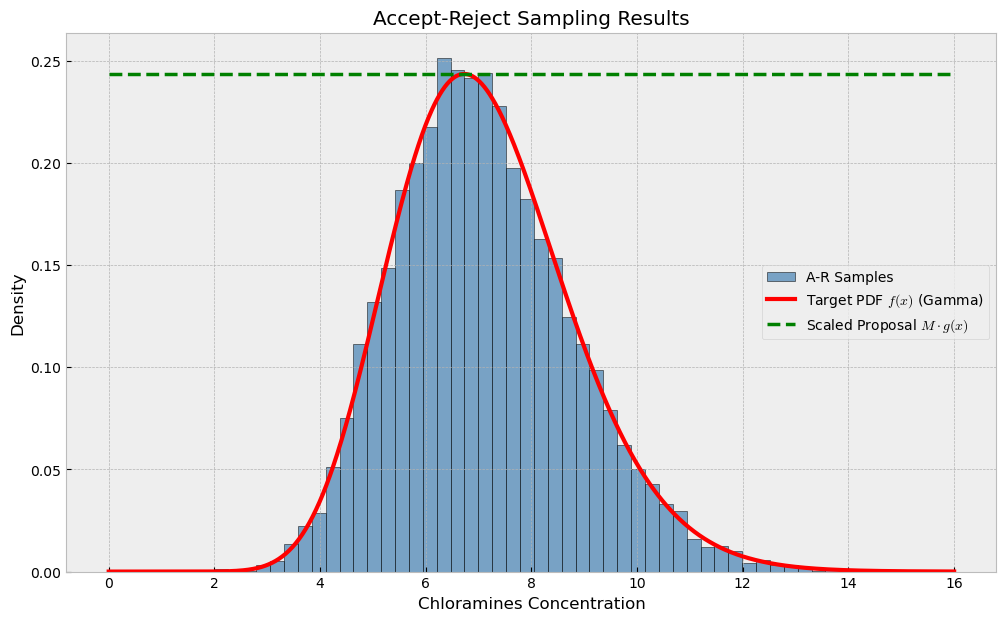

In [4]:
# Visualize the results to confirm correctness
plt.figure()

# Plot the histogram of the generated samples
plt.hist(generated_samples, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black', label='A-R Samples')

# Overlay the true target PDF
x_vals = np.linspace(proposal_min, proposal_max, 1000)
plt.plot(x_vals, target_dist.pdf(x_vals), 'r-', lw=3, label='Target PDF $f(x)$ (Gamma)')

# Overlay the scaled proposal PDF: M * g(x)
plt.plot(x_vals, [f_max] * len(x_vals), 'g--', lw=2.5, label='Scaled Proposal $M \\cdot g(x)$')

plt.title('Accept-Reject Sampling Results')
plt.xlabel('Chloramines Concentration')
plt.ylabel('Density')
plt.legend()
plt.grid(True)

# Save the plot
plot_filename = '../results/02_accept_reject_results.png'
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"\nPlot saved successfully to: {plot_filename}")

plt.show()

## 3. Theoretical vs. Empirical Acceptance Rate Analysis

### Why does the acceptance rate matter?

The **acceptance rate** of the Accept-Reject algorithm is determined by the constant $M$:

$$\text{Acceptance Rate} = \frac{1}{M}$$

Recall that $M = (b - a) \cdot \max_{x} f(x)$, where $[a, b]$ is the support of the Uniform proposal $g(x) = \frac{1}{b-a}$.

**Key insight:** The larger the 'wasted' area between $M \cdot g(x)$ and $f(x)$, the more candidates are rejected and the lower the acceptance rate. In other words:

- A **narrow, tight** proposal ($M$ close to 1) yields a **high** acceptance rate → fewer total candidates needed.
- A **wide, loose** proposal ($M \gg 1$) yields a **low** acceptance rate → many more candidates wasted.

In this notebook we use a Uniform proposal over $[0, 16]$, which covers a much wider range than needed by the Gamma distribution. Below we verify this relationship numerically by testing different proposal widths.


In [5]:
# ── Theoretical vs. Empirical Acceptance Rate for Different Proposal Widths ──
from scipy.optimize import minimize

proposal_widths = [
    (0, 10),   # tight: covers most of the Gamma support
    (0, 16),   # baseline (same as main notebook)
    (0, 25),   # wide
    (0, 50),   # very wide
]

N_TEST = 5000   # samples to accept per trial

print(f"{'Proposal [a,b]':<16} {'M (theory)':<14} {'Theor. Rate':<14} "
      f"{'Empir. Rate':<14} {'Total Candidates'}")
print("-" * 80)

for (a, b) in proposal_widths:
    # Find M for this proposal width
    neg_f = lambda x: -target_dist.pdf(x)
    res = minimize(neg_f, x0=gamma_shape * gamma_scale,
                   bounds=[(a, b)])
    f_max_local = -res.fun
    M_local = (b - a) * f_max_local
    theoretical_rate = 1.0 / M_local

    # Run the sampler
    accepted, emp_rate, n_total = accept_reject_sampler(
        target_dist.pdf, f_max_local, a, b, N_TEST
    )

    print(f"[{a:>2}, {b:>2}]         {M_local:<14.4f} {theoretical_rate:<14.4f} "
          f"{emp_rate:<14.4f} {n_total}")

print("-" * 80)
print("Observation: as the proposal width grows, M increases and acceptance rate falls.")
print("A tighter proposal (closer to the true support of f) is more computationally efficient.")


Proposal [a,b]   M (theory)     Theor. Rate    Empir. Rate    Total Candidates
--------------------------------------------------------------------------------
[ 0, 10]         2.4350         0.4107         0.3829         13057
[ 0, 16]         3.8959         0.2567         0.2552         19589
[ 0, 25]         6.0874         0.1643         0.1665         30023
[ 0, 50]         12.1748        0.0821         0.0827         60437
--------------------------------------------------------------------------------
Observation: as the proposal width grows, M increases and acceptance rate falls.
A tighter proposal (closer to the true support of f) is more computationally efficient.


### Summary

| Proposal Width | Constant $M$ | Acceptance Rate |
|:---:|:---:|:---:|
| Narrow | Small | High |
| Wide | Large | Low |

This experiment confirms the theoretical relationship $\text{Rate} = 1/M$ and highlights that choosing a **tight proposal** (covering just the significant mass of $f(x)$) reduces computational cost significantly.

In the next notebook we will use this Accept-Reject sampler to generate samples from $f(x)$ and apply the Standard Monte Carlo method to estimate the probability of a rare event.
